# 03 — TFT Forecaster
### Standard Temporal Fusion Transformer — Event-Based Breakdown Forecasting
> Run 00_Data_Preparation.ipynb first.
>
> **Model A:** Binary forecaster (breakdown coming within H=15 events?)
> **Model B:** Type forecaster (which breakdown type is coming?)


In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, mean_squared_error, mean_absolute_error,
    recall_score, precision_score
)
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [3]:
with open('prepared_forecasting.pkl','rb') as f: d = pickle.load(f)
with open('encoder_reason.pkl','rb') as f: encoder_reason = pickle.load(f)

X_train      = torch.FloatTensor(d['X_fc_train_seq']).to(DEVICE)
X_test       = torch.FloatTensor(d['X_fc_test_seq']).to(DEVICE)
y_train_bin  = torch.LongTensor(d['y_fc_train_bin_seq']).to(DEVICE)
y_test_bin   = torch.LongTensor(d['y_fc_test_bin_seq']).to(DEVICE)
y_train_type = torch.LongTensor(d['y_fc_train_type_seq']).to(DEVICE)
y_test_type  = torch.LongTensor(d['y_fc_test_type_seq']).to(DEVICE)

NUM_FEATURES       = d['num_features']
TIME_STEPS         = d['TIME_STEPS']
H                  = d['H']
NUM_REASON_CLASSES = d['num_reason_classes']

# Binary class counts
cc_bin = np.bincount(d['y_fc_train_bin_seq'])

# Dataset is already balanced — use normal DataLoader with shuffle
train_loader_bin = DataLoader(
    TensorDataset(X_train, y_train_bin),
    batch_size=32,
    shuffle=True
)

print(f'✅ Data loaded.')
print(f'   Features   : {NUM_FEATURES}, TIME_STEPS: {TIME_STEPS}, H: {H}')
print(f'   Binary class counts (train): {cc_bin}')
print(f'   Safe %                     : {(d["y_fc_train_bin_seq"]==0).mean()*100:.1f}%')
print(f'   Breakdown %                : {(d["y_fc_train_bin_seq"]==1).mean()*100:.1f}%')
print(f'   Reason classes             : {list(encoder_reason.classes_)}')


✅ Data loaded.
   Features   : 67, TIME_STEPS: 20, H: 15
   Binary class counts (train): [9610 2430]
   Safe %                     : 79.8%
   Breakdown %                : 20.2%
   Reason classes             : ['High Thread Tension', 'High foot pressure', 'No Breakdown', 'Running with no thread']


---
## TFT Architecture
> hidden_size=64, num_heads=4, 2 LSTM layers, dropout=0.3


In [4]:
class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class TFT_Forecaster(nn.Module):
    def __init__(self, num_features, time_steps, num_classes,
                 hidden_size=64, num_heads=4, dropout=0.3):
        super().__init__()
        self.time_steps    = time_steps
        self.input_proj    = GRN(num_features, hidden_size, hidden_size, dropout)
        self.lstm_encoder  = nn.LSTM(hidden_size, hidden_size, 2,
                                     batch_first=True, dropout=dropout)
        self.attention     = nn.MultiheadAttention(hidden_size, num_heads,
                                                    dropout=dropout, batch_first=True)
        self.attn_norm     = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        proj_out = [self.input_proj(x[:, t, :]) for t in range(self.time_steps)]
        proj_seq = torch.stack(proj_out, dim=1)
        lstm_out, _ = self.lstm_encoder(proj_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(attn_out + lstm_out)
        out = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)


---
## Model A — Binary Forecaster
> Predicts: will a breakdown happen within the next H=15 events?


In [5]:
model_a = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=2, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'TFT Model A (Binary) parameters: {sum(p.numel() for p in model_a.parameters()):,}')


TFT Model A (Binary) parameters: 115,234


Training TFT Model A (Binary Forecaster)...
Epoch   1 | Train: 0.2946 | Val: 0.2675
Epoch   2 | Train: 0.2100 | Val: 0.2718
Epoch   3 | Train: 0.1486 | Val: 0.3921
Epoch   4 | Train: 0.1069 | Val: 0.5431
Epoch   5 | Train: 0.0846 | Val: 0.5902
Epoch   6 | Train: 0.0695 | Val: 0.6906
Epoch   7 | Train: 0.0594 | Val: 0.8648
Epoch   8 | Train: 0.0536 | Val: 0.9552
Epoch   9 | Train: 0.0451 | Val: 0.8925
Epoch  10 | Train: 0.0423 | Val: 0.8252
Epoch  11 | Train: 0.0409 | Val: 1.0146
Epoch  12 | Train: 0.0329 | Val: 1.2946
Epoch  13 | Train: 0.0311 | Val: 1.2402
Epoch  14 | Train: 0.0253 | Val: 1.5975
Epoch  15 | Train: 0.0227 | Val: 1.4701
Early stopping at epoch 16

✅ Best val loss: 0.2675 — best checkpoint restored.


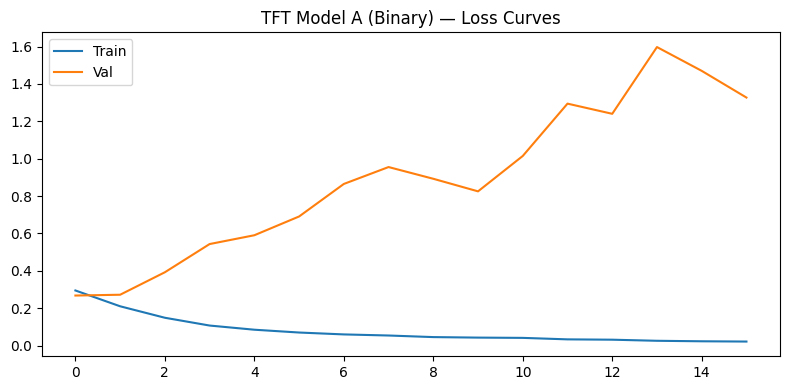

In [ ]:
EPOCHS    = 25
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-3)
cc_bin_counts = np.bincount(d['y_fc_train_bin_seq'])
cw = len(cc_bin_counts) / (cc_bin_counts * 2.0)
criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(cw).to(DEVICE)
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 15
train_losses, val_losses = [], []

print('Training TFT Model A (Binary Forecaster)...')
for epoch in range(EPOCHS):
    model_a.train()
    batch_losses = []
    for xb, yb in train_loader_bin:
        optimizer.zero_grad()
        loss = criterion(model_a(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    model_a.eval()
    with torch.no_grad():
        val_loss = criterion(model_a(X_test), y_test_bin).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_a.state_dict(), 'best_tft_binary.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

model_a.load_state_dict(torch.load('best_tft_binary.pt'))
print(f'\n✅ Best val loss: {best_val_loss:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('TFT Model A (Binary) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_binary_loss.png', dpi=150); plt.show()


#### Evaluate Model A


TFT MODEL A — BINARY FORECASTER RESULTS (threshold=0.5)
Accuracy : 94.52%
F1 Score : 0.9447
RMSE     : 0.2340
MAE      : 0.0548

                  precision    recall  f1-score   support

            Safe       0.96      0.97      0.97      2410
Breakdown Coming       0.88      0.83      0.86       585

        accuracy                           0.95      2995
       macro avg       0.92      0.90      0.91      2995
    weighted avg       0.94      0.95      0.94      2995



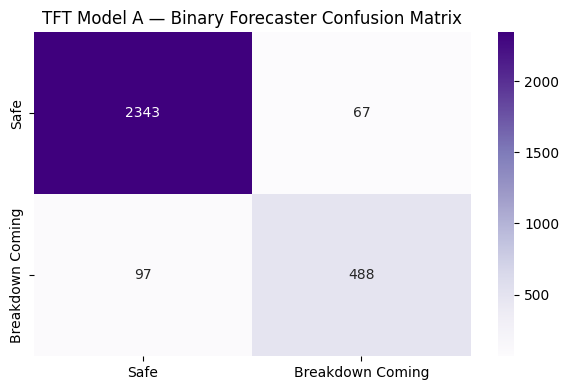

THRESHOLD ANALYSIS
(Higher recall = safer system for predictive maintenance)
 Threshold | Accuracy | BD Recall | BD Precision |     F1
-------------------------------------------------------
      0.50 |   94.52% |      0.83 |         0.88 | 0.9447
      0.40 |   94.36% |      0.84 |         0.87 | 0.9433
      0.30 |   94.12% |      0.85 |         0.85 | 0.9412
      0.25 |   93.66% |      0.85 |         0.83 | 0.9369
      0.20 |   92.99% |      0.86 |         0.80 | 0.9308
      0.15 |   91.25% |      0.88 |         0.73 | 0.9154
      0.10 |   86.91% |      0.90 |         0.61 | 0.8777

✅ Best threshold by F1: 0.5 (F1=0.9447)


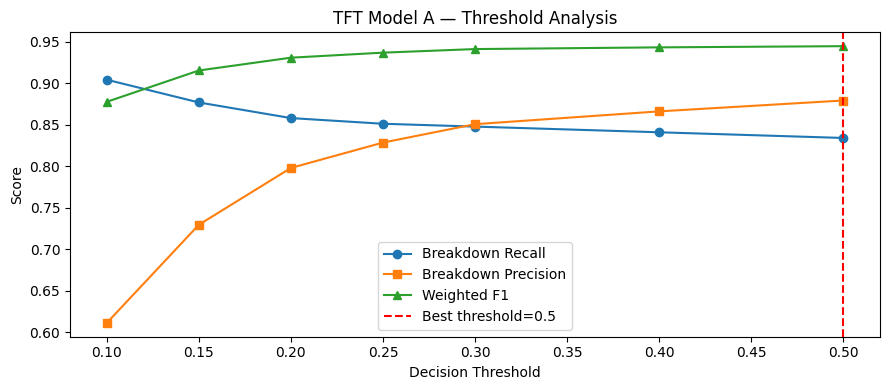


=== FINAL RESULTS AT OPTIMAL THRESHOLD (0.5) ===
                  precision    recall  f1-score   support

            Safe       0.96      0.97      0.97      2410
Breakdown Coming       0.88      0.83      0.86       585

        accuracy                           0.95      2995
       macro avg       0.92      0.90      0.91      2995
    weighted avg       0.94      0.95      0.94      2995

✅ Model A results saved.


In [7]:
model_a.eval()
with torch.no_grad():
    probs_all       = torch.softmax(model_a(X_test), dim=1).cpu().numpy()
    y_pred_bin      = np.argmax(probs_all, axis=1)
    y_true_bin      = y_test_bin.cpu().numpy()
    breakdown_probs = probs_all[:, 1]

acc  = accuracy_score(y_true_bin, y_pred_bin)
f1   = f1_score(y_true_bin, y_pred_bin, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true_bin, y_pred_bin))
mae  = mean_absolute_error(y_true_bin, y_pred_bin)

print('='*55)
print('TFT MODEL A — BINARY FORECASTER RESULTS (threshold=0.5)')
print('='*55)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true_bin, y_pred_bin, target_names=['Safe','Breakdown Coming']))

cm = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Safe','Breakdown Coming'],
            yticklabels=['Safe','Breakdown Coming'])
plt.title('TFT Model A — Binary Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_binary_confusion.png', dpi=150); plt.show()

# ── THRESHOLD ANALYSIS ────────────────────────────────────────────────────────
print('='*55)
print('THRESHOLD ANALYSIS')
print('(Higher recall = safer system for predictive maintenance)')
print('='*55)
print(f'{"Threshold":>10} | {"Accuracy":>8} | {"BD Recall":>9} | {"BD Precision":>12} | {"F1":>6}')
print('-'*55)

best_threshold = 0.5
best_f1 = 0
threshold_results = []

for threshold in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    y_pred_t = (breakdown_probs >= threshold).astype(int)
    acc_t    = accuracy_score(y_true_bin, y_pred_t)
    f1_t     = f1_score(y_true_bin, y_pred_t, average='weighted')
    rec_bd   = recall_score(y_true_bin, y_pred_t, pos_label=1)
    pre_bd   = precision_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    print(f'{threshold:>10.2f} | {acc_t*100:>7.2f}% | {rec_bd:>9.2f} | {pre_bd:>12.2f} | {f1_t:>6.4f}')
    threshold_results.append((threshold, acc_t, rec_bd, pre_bd, f1_t))
    if f1_t > best_f1:
        best_f1 = f1_t
        best_threshold = threshold

print(f'\n✅ Best threshold by F1: {best_threshold} (F1={best_f1:.4f})')

# Plot threshold analysis
thresholds = [r[0] for r in threshold_results]
recalls    = [r[2] for r in threshold_results]
precisions = [r[3] for r in threshold_results]
f1s        = [r[4] for r in threshold_results]

plt.figure(figsize=(9,4))
plt.plot(thresholds, recalls,    marker='o', label='Breakdown Recall')
plt.plot(thresholds, precisions, marker='s', label='Breakdown Precision')
plt.plot(thresholds, f1s,        marker='^', label='Weighted F1')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('TFT Model A — Threshold Analysis')
plt.legend(); plt.tight_layout()
plt.savefig('tft_binary_threshold.png', dpi=150); plt.show()

# Save results
y_pred_best = (breakdown_probs >= best_threshold).astype(int)
acc_best  = accuracy_score(y_true_bin, y_pred_best)
f1_best   = f1_score(y_true_bin, y_pred_best, average='weighted')
rmse_best = np.sqrt(mean_squared_error(y_true_bin, y_pred_best))
mae_best  = mean_absolute_error(y_true_bin, y_pred_best)

print(f'\n=== FINAL RESULTS AT OPTIMAL THRESHOLD ({best_threshold}) ===')
print(classification_report(y_true_bin, y_pred_best, target_names=['Safe','Breakdown Coming']))

tft_binary_results = {
    'model'          : 'TFT Forecaster',
    'accuracy'       : acc_best,
    'f1'             : f1_best,
    'rmse'           : rmse_best,
    'mae'            : mae_best,
    'best_threshold' : best_threshold,
}
with open('tft_binary_results.pkl','wb') as f: pickle.dump(tft_binary_results, f)
print('✅ Model A results saved.')


---
## Model B — Type Forecaster
> Trained only on records where breakdown IS coming.
> Predicts which breakdown type is approaching.


In [8]:
# Filter: only sequences where breakdown IS coming
mask_train = d['y_fc_train_bin_seq'] == 1
mask_test  = d['y_fc_test_bin_seq'] == 1

X_tr_type = torch.FloatTensor(d['X_fc_train_seq'][mask_train]).to(DEVICE)
X_te_type = torch.FloatTensor(d['X_fc_test_seq'][mask_test]).to(DEVICE)
y_tr_type = torch.LongTensor(d['y_fc_train_type_seq'][mask_train]).to(DEVICE)
y_te_type = torch.LongTensor(d['y_fc_test_type_seq'][mask_test]).to(DEVICE)

unique_types_train = np.unique(d['y_fc_train_type_seq'][mask_train])
print(f'✅ Type forecaster data ready.')
print(f'   Train: {X_tr_type.shape}  Test: {X_te_type.shape}')
print(f'   Unique breakdown types in train: {unique_types_train}')

if len(unique_types_train) > 1:
    cc_type  = np.bincount(d['y_fc_train_type_seq'][mask_train])
    cw_type  = np.where(cc_type > 0, 1.0 / cc_type, 0.0)
    cw_type  = cw_type / cw_type[cw_type > 0].sum() * (cc_type > 0).sum()
    weights_type = torch.FloatTensor(cw_type).to(DEVICE)
    print(f'   Type class counts  : {cc_type}')
    print(f'   Type class weights : {cw_type.round(3)}')
else:
    weights_type = torch.ones(NUM_REASON_CLASSES, dtype=torch.float32).to(DEVICE)
    print('⚠️  Only one breakdown type in training data — using uniform weights.')

train_loader_type = DataLoader(TensorDataset(X_tr_type, y_tr_type), batch_size=32, shuffle=True)


✅ Type forecaster data ready.
   Train: torch.Size([2430, 20, 67])  Test: torch.Size([585, 20, 67])
   Unique breakdown types in train: [0 1 3]
   Type class counts  : [810 810   0 810]
   Type class weights : [1. 1. 0. 1.]


TFT Model B (Type) parameters: 32,132
Training TFT Model B (Type Forecaster)...
Epoch   1 | Train: 1.1642 | Val: 0.9733
Epoch   2 | Train: 0.9158 | Val: 0.7753
Epoch   3 | Train: 0.7281 | Val: 0.6268
Epoch   4 | Train: 0.6013 | Val: 0.5114
Epoch   5 | Train: 0.4898 | Val: 0.4351
Epoch   6 | Train: 0.4101 | Val: 0.3836
Epoch   7 | Train: 0.3531 | Val: 0.3499
Epoch   8 | Train: 0.3155 | Val: 0.3288
Epoch   9 | Train: 0.2881 | Val: 0.3154
Epoch  10 | Train: 0.2636 | Val: 0.3078
Epoch  11 | Train: 0.2333 | Val: 0.3046
Epoch  12 | Train: 0.2027 | Val: 0.3073
Epoch  13 | Train: 0.1980 | Val: 0.3029
Epoch  14 | Train: 0.1929 | Val: 0.2996
Epoch  15 | Train: 0.1743 | Val: 0.3018
Epoch  16 | Train: 0.1711 | Val: 0.3098
Epoch  17 | Train: 0.1646 | Val: 0.3111
Epoch  18 | Train: 0.1476 | Val: 0.3106
Epoch  19 | Train: 0.1442 | Val: 0.3079
Epoch  20 | Train: 0.1473 | Val: 0.3124
Epoch  21 | Train: 0.1351 | Val: 0.3167
Epoch  22 | Train: 0.1348 | Val: 0.3236
Epoch  23 | Train: 0.1261 | Val: 0.3207


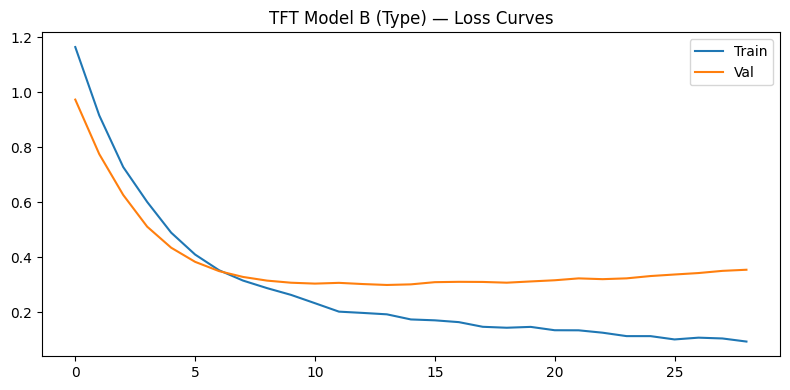

In [ ]:
model_b = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=NUM_REASON_CLASSES, hidden_size=32, num_heads=2, dropout=0.4
).to(DEVICE)
print(f'TFT Model B (Type) parameters: {sum(p.numel() for p in model_b.parameters()):,}')

EPOCHS      = 50
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=1e-4)
criterion_b = nn.CrossEntropyLoss(weight=weights_type)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=50)

best_val_loss_b = float('inf')
patience_b      = 0
PATIENCE_B      = 15
train_losses_b, val_losses_b = [], []

print('Training TFT Model B (Type Forecaster)...')
for epoch in range(EPOCHS):
    model_b.train()
    batch_losses = []
    for xb, yb in train_loader_type:
        optimizer_b.zero_grad()
        loss = criterion_b(model_b(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_b.parameters(), 1.0)
        optimizer_b.step()
        batch_losses.append(loss.item())
    scheduler_b.step()

    model_b.eval()
    with torch.no_grad():
        val_loss = criterion_b(model_b(X_te_type), y_te_type).item()
    train_loss = np.mean(batch_losses)
    train_losses_b.append(train_loss)
    val_losses_b.append(val_loss)

    if val_loss < best_val_loss_b:
        best_val_loss_b = val_loss
        torch.save(model_b.state_dict(), 'best_tft_type.pt')
        patience_b = 0
    else:
        patience_b += 1
        if patience_b >= PATIENCE_B:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

model_b.load_state_dict(torch.load('best_tft_type.pt'))
print(f'\n✅ Best val loss: {best_val_loss_b:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses_b, label='Train')
plt.plot(val_losses_b, label='Val')
plt.title('TFT Model B (Type) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_type_loss.png', dpi=150); plt.show()


#### Evaluate Model B


TFT MODEL B — TYPE FORECASTER RESULTS
Accuracy : 88.72%
F1 Score : 0.8872

                        precision    recall  f1-score   support

   High Thread Tension       0.91      0.87      0.89       195
    High foot pressure       0.88      0.89      0.88       195
Running with no thread       0.88      0.90      0.89       195

              accuracy                           0.89       585
             macro avg       0.89      0.89      0.89       585
          weighted avg       0.89      0.89      0.89       585



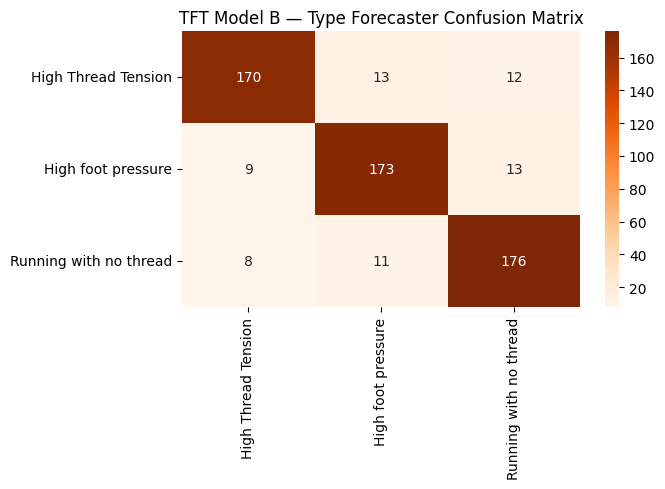

✅ Model B results saved.


In [10]:
model_b.eval()
with torch.no_grad():
    y_pred_type = np.argmax(torch.softmax(model_b(X_te_type), dim=1).cpu().numpy(), axis=1)
    y_true_type = y_te_type.cpu().numpy()

unique_labels = sorted(set(y_true_type) | set(y_pred_type))
label_names   = [encoder_reason.classes_[i] for i in unique_labels]

print('='*50)
print('TFT MODEL B — TYPE FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {accuracy_score(y_true_type, y_pred_type)*100:.2f}%')
print(f'F1 Score : {f1_score(y_true_type, y_pred_type, average="weighted"):.4f}')
print()
print(classification_report(y_true_type, y_pred_type, labels=unique_labels, target_names=label_names))

cm = confusion_matrix(y_true_type, y_pred_type, labels=unique_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('TFT Model B — Type Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_type_confusion.png', dpi=150); plt.show()

tft_type_results = {
    'model'   : 'TFT Forecaster Type',
    'accuracy': accuracy_score(y_true_type, y_pred_type),
    'f1'      : f1_score(y_true_type, y_pred_type, average='weighted'),
}
with open('tft_type_results.pkl','wb') as f: pickle.dump(tft_type_results, f)
print('✅ Model B results saved.')


#### Save Artifacts


In [11]:
tft_forecast_config = {
    'num_features'      : NUM_FEATURES,
    'time_steps'        : TIME_STEPS,
    'H'                 : H,
    'num_classes_binary': 2,
    'num_classes_type'  : NUM_REASON_CLASSES,
    'hidden_size'       : 64,
    'num_heads'         : 4,
}
with open('tft_forecast_config.pkl','wb') as f: pickle.dump(tft_forecast_config, f)
print('✅ Saved: best_tft_binary.pt | best_tft_type.pt | tft_forecast_config.pkl')
print(f'   tft_binary_results.pkl | tft_type_results.pkl')


✅ Saved: best_tft_binary.pt | best_tft_type.pt | tft_forecast_config.pkl
   tft_binary_results.pkl | tft_type_results.pkl
